# NB 12 — Sparse PCA per-block + Cooperative Learning + argmax (R)

## Objet

Tester en R, avec le solveur de référence `multiview` (mature, glmnet-based), la variante **Sparse PCA per-block → Cooperative → argmax**.

## Motivation

Dans NB07 (Python, solveur FISTA custom), nous avons observé que :
- **Cooperative raw** : ρ=0 → 0.69, ρ>0 s'effondre à ~0.45 (non-convergence du solveur en p=16931)
- **Cooperative + Sparse PCA per-block** : ρ=0.1 atteint 0.69 (pic), ρ>0 reste robuste autour de 0.60-0.69

C'est le **seul régime où ρ > 0 apporte un bénéfice** observé empiriquement. Mais en Python custom les chiffres absolus sont bas (0.69).

En R via multiview (NB11), **cooperative raw à ρ=0 atteint 0.83**. Question naturelle : **est-ce que Sparse PCA per-block en amont peut faire encore mieux** ?

Hypothèse : la Sparse PCA réduit la dimensionnalité de 16931 à ~20, ce qui :
1. Rend le solveur cooperative beaucoup plus tractable pour ρ > 0 (problème de conditionnement résolu)
2. Pré-sélectionne des combinaisons de variables sparses, biologiquement interprétables
3. Pourrait permettre à l'agrément cross-blocs d'apporter un bénéfice

## Pipeline

```
X_GE  (39 × 15702) ─┐                                    ┌─ score_GE^cort  ─┐
                    │                                    │                  │
                    ├─ Sparse PCA per-block ─┐           ├─ score_GE^dipg  ─┤
                    │   (ncomp_GE = 10,      │           │                  │     argmax
X_CGH (39 × 1229) ──┤    ncomp_CGH = 5)      ├─ Coop ──> ├─ score_GE^midl  ─├──> classe
                    │                        │   OvR     │                  │     prédite
                    │                        │           ├─ score_CGH^cort ─┤
                    │                        │           ├─ score_CGH^dipg ─┤
                    │                        │           └─ score_CGH^midl ─┘
                    │                        │
                    └────────────────────────┘
                       Z_train (39 × 15)
                       Z_train (39 × 5)
```

Comparaison directe à NB11 (cooperative raw) et NB09 (SGCCA + LDA).


## 1. Setup

In [2]:
set.seed(42)
SEED <- 42
LABEL_ORDER <- c("cort", "dipg", "midl")

# multiview, data.table, caret, MASS depuis CRAN
cran_packages <- c("multiview", "data.table", "caret", "MASS", "elasticnet")
to_install <- cran_packages[!vapply(cran_packages, requireNamespace,
                                    logical(1), quietly = TRUE)]
if (length(to_install) > 0) {
  install.packages(to_install, repos = "https://cloud.r-project.org")
}

# mixOmics : préférence Bioconductor, fallback sur elasticnet pour Sparse PCA
USE_MIXOMICS <- requireNamespace("mixOmics", quietly = TRUE)
if (!USE_MIXOMICS) {
  cat("mixOmics non disponible — tentative d'installation via BiocManager...\n")
  if (!requireNamespace("BiocManager", quietly = TRUE)) {
    install.packages("BiocManager", repos = "https://cloud.r-project.org")
  }
  tryCatch({
    BiocManager::install("mixOmics", update = FALSE, ask = FALSE)
    USE_MIXOMICS <- requireNamespace("mixOmics", quietly = TRUE)
  }, error = function(e) {
    cat("Installation mixOmics échouée. Fallback sur elasticnet::spca.\n")
    USE_MIXOMICS <<- FALSE
  })
}

suppressPackageStartupMessages({
  library(multiview)
  library(data.table)
  library(caret)
  library(MASS)
  library(elasticnet)
  if (USE_MIXOMICS) library(mixOmics)
})

cat("multiview     :", as.character(packageVersion("multiview")), "\n")
cat("elasticnet    :", as.character(packageVersion("elasticnet")), "\n")
cat("USE_MIXOMICS  :", USE_MIXOMICS, "\n")
if (USE_MIXOMICS) cat("mixOmics      :", as.character(packageVersion("mixOmics")), "\n")


multiview     : 0.8 
elasticnet    : 1.3 
USE_MIXOMICS  : TRUE 
mixOmics      : 6.36.0 


## 2. Chargement des données (identique à NB10/NB11)

In [3]:
root <- normalizePath(file.path(getwd()), winslash = "/", mustWork = FALSE)
data_dir <- if (dir.exists(file.path(root, "data"))) file.path(root, "data") else file.path(dirname(root), "data")

to_numeric_frame <- function(df) {
  rn <- rownames(df)
  out <- as.data.frame(
    lapply(df, function(x) as.numeric(gsub(",", ".", as.character(x), fixed = TRUE))),
    check.names = FALSE
  )
  rownames(out) <- rn
  out
}

extract_id_column <- function(df) if ("row_id" %in% names(df)) "row_id" else names(df)[1]

load_block <- function(block_name, split) {
  path <- file.path(data_dir,
    sprintf("ge_cgh_locIGR__multiblocks__%s__%s.csv", block_name, split))
  df <- as.data.frame(data.table::fread(path, check.names = FALSE))
  id_col <- extract_id_column(df)
  rownames(df) <- as.character(df[[id_col]])
  df[[id_col]] <- NULL
  to_numeric_frame(df)
}

load_targets <- function(split) {
  path <- file.path(data_dir,
    sprintf("ge_cgh_locIGR__multiblocks__y__%s.csv", split))
  y_df <- as.data.frame(data.table::fread(path, check.names = FALSE))
  id_col <- extract_id_column(y_df)
  rownames(y_df) <- as.character(y_df[[id_col]])
  y_df[[id_col]] <- NULL
  targets <- factor(
    LABEL_ORDER[max.col(as.matrix(y_df[, LABEL_ORDER]), ties.method = "first")],
    levels = LABEL_ORDER
  )
  names(targets) <- rownames(y_df)
  targets
}

fill_missing_from_train <- function(train_df, test_df) {
  medians <- vapply(train_df, median, numeric(1), na.rm = TRUE)
  for (col in names(train_df)) {
    train_df[[col]][is.na(train_df[[col]])] <- medians[[col]]
    test_df[[col]][is.na(test_df[[col]])] <- medians[[col]]
  }
  list(train = train_df, test = test_df)
}

X_ge_train  <- load_block("GE",  "train")
X_ge_test   <- load_block("GE",  "test")
X_cgh_train <- load_block("CGH", "train")
X_cgh_test  <- load_block("CGH", "test")
y_train     <- load_targets("train")
y_test      <- load_targets("test")

train_ids <- Reduce(intersect, list(rownames(X_ge_train), rownames(X_cgh_train), names(y_train)))
test_ids  <- Reduce(intersect, list(rownames(X_ge_test),  rownames(X_cgh_test),  names(y_test)))

X_ge_train  <- X_ge_train [train_ids, , drop = FALSE]
X_cgh_train <- X_cgh_train[train_ids, , drop = FALSE]
y_train     <- y_train    [train_ids]
X_ge_test   <- X_ge_test  [test_ids,  , drop = FALSE]
X_cgh_test  <- X_cgh_test [test_ids,  , drop = FALSE]
y_test      <- y_test     [test_ids]

filled_ge  <- fill_missing_from_train(X_ge_train,  X_ge_test)
X_ge_train <- filled_ge$train;  X_ge_test  <- filled_ge$test
filled_cgh  <- fill_missing_from_train(X_cgh_train, X_cgh_test)
X_cgh_train <- filled_cgh$train; X_cgh_test <- filled_cgh$test

X_ge_train  <- as.matrix(X_ge_train)
X_ge_test   <- as.matrix(X_ge_test)
X_cgh_train <- as.matrix(X_cgh_train)
X_cgh_test  <- as.matrix(X_cgh_test)

cat(sprintf("Train: %d patients | Test: %d patients\n", length(y_train), length(y_test)))
cat(sprintf("GE: %d features | CGH: %d features\n",
            ncol(X_ge_train), ncol(X_cgh_train)))


Train: 39 patients | Test: 14 patients
GE: 15702 features | CGH: 1229 features


## 3. Sparse PCA par bloc avec `mixOmics::spca`

On applique une **Sparse PCA séparément à chaque bloc** (analogue à `BlockSparsePCATransformer` en Python).

**Hyperparamètres** :
- `ncomp` : nombre de composantes par bloc (10 pour GE, 5 pour CGH — proportionnel à la taille des blocs)
- `keepX` : nombre de variables non-nulles **par composante** (sparsité des chargements)

On standardise dans `spca` avec `scale = TRUE` (mean=0, sd=1 par variable).


In [4]:
# Sparse PCA per-block
N_COMP_GE  <- 10
N_COMP_CGH <- 5
KEEP_GE    <- 80   # variables non-nulles par composante GE
KEEP_CGH   <- 30   # variables non-nulles par composante CGH

# ---- Wrapper Sparse PCA robuste : centrage/scaling MANUELS + spca ----
# On ne dépend pas de la structure interne de mixOmics (qui change entre versions).
# On centre et scale nous-mêmes, on passe scale=FALSE/center=FALSE à mixOmics,
# et on stocke nos propres statistiques pour la projection sur de nouvelles données.
fit_spca <- function(X, ncomp, keep_per_comp) {
  # 1) Centrage et scaling manuels (stats train uniquement)
  X_center <- colMeans(X)
  X_scale  <- apply(X, 2, sd)
  X_scale[X_scale < 1e-10] <- 1   # éviter division par 0 pour colonnes constantes
  X_scaled <- sweep(sweep(X, 2, X_center, "-"), 2, X_scale, "/")

  # 2) Sparse PCA sur données déjà centrées
  if (USE_MIXOMICS) {
    fit <- mixOmics::spca(
      X_scaled, ncomp = ncomp,
      keepX = rep(keep_per_comp, ncomp),
      scale = FALSE, center = FALSE   # ← centrage déjà fait
    )
    loadings <- as.matrix(fit$loadings$X)
    var_expl <- tryCatch(as.numeric(fit$prop_expl_var$X), error = function(e) NULL)
    backend  <- "mixOmics"
  } else {
    fit <- elasticnet::spca(
      X_scaled, K = ncomp,
      para = rep(keep_per_comp, ncomp),
      type = "predictor", sparse = "varnum",
      lambda = 1e-6, use.corr = FALSE, trace = FALSE
    )
    loadings <- as.matrix(fit$loadings)
    var_expl <- NULL
    backend  <- "elasticnet"
  }

  # 3) Scores train via la projection (équivalent au $variates$X de mixOmics)
  variates <- X_scaled %*% loadings

  list(
    backend  = backend,
    loadings = loadings,    # p × ncomp
    variates = variates,    # n × ncomp
    center   = X_center,    # vecteur p
    scale    = X_scale,     # vecteur p
    var_expl = var_expl
  )
}

# Projection sur nouvelles données (utilise les stats train)
project_spca <- function(X_new, spca_obj) {
  X_scaled <- sweep(sweep(X_new, 2, spca_obj$center, "-"), 2, spca_obj$scale, "/")
  X_scaled %*% spca_obj$loadings
}

# Sparse PCA per-block sur le train
cat("\nSparse PCA bloc GE (backend = ", ifelse(USE_MIXOMICS, "mixOmics", "elasticnet"), ")...\n", sep="")
spca_ge  <- fit_spca(X_ge_train,  N_COMP_GE,  KEEP_GE)

cat("Sparse PCA bloc CGH...\n")
spca_cgh <- fit_spca(X_cgh_train, N_COMP_CGH, KEEP_CGH)

# Composantes (scores) sur train
Z_ge_train  <- spca_ge$variates
Z_cgh_train <- spca_cgh$variates

# Projeter le test sur les mêmes axes
Z_ge_test  <- project_spca(X_ge_test,  spca_ge)
Z_cgh_test <- project_spca(X_cgh_test, spca_cgh)

cat(sprintf("\nDim Z_ge_train  : %d × %d\n", nrow(Z_ge_train),  ncol(Z_ge_train)))
cat(sprintf("Dim Z_cgh_train : %d × %d\n", nrow(Z_cgh_train), ncol(Z_cgh_train)))

# Variance expliquée (si dispo)
if (!is.null(spca_ge$var_expl)) {
  cat("\nVariance expliquée par composante :\n")
  cat(sprintf("  GE  : %s%%\n", paste(round(spca_ge$var_expl * 100, 1), collapse=" ")))
  cat(sprintf("  CGH : %s%%\n", paste(round(spca_cgh$var_expl * 100, 1), collapse=" ")))
}

# Sparsité effective (nombre de variables non-nulles par composante)
cat("\nSparsité effective (variables non-nulles par composante) :\n")
cat(sprintf("  GE  : %s\n", paste(colSums(abs(spca_ge$loadings)  > 1e-10), collapse=" ")))
cat(sprintf("  CGH : %s\n", paste(colSums(abs(spca_cgh$loadings) > 1e-10), collapse=" ")))



Sparse PCA bloc GE (backend = mixOmics)...


Warning message in mixOmics::spca(X_scaled, ncomp = ncomp, keepX = rep(keep_per_comp, :
“data contain missing values which will be set to zero for calculations. Consider using center = TRUE for better performance, or impute missing values using 'impute.nipals' function.”


Sparse PCA bloc CGH...


Warning message in mixOmics::spca(X_scaled, ncomp = ncomp, keepX = rep(keep_per_comp, :
“data contain missing values which will be set to zero for calculations. Consider using center = TRUE for better performance, or impute missing values using 'impute.nipals' function.”



Dim Z_ge_train  : 39 × 10
Dim Z_cgh_train : 39 × 5

Variance expliquée par composante :
  GE  : 8.3 7.4 6.3 6.7 4.6 4.3 4.7 3.7 3.6 3.2%
  CGH : 10.4 10.3 8.4 6.3 5.1%

Sparsité effective (variables non-nulles par composante) :
  GE  : 80 80 80 80 80 80 80 80 80 80
  CGH : 30 30 30 30 30


## 4. Concaténation des composantes réduites

On concatène les 10 PC GE et 5 PC CGH en une matrice 39 × 15 avec préfixes `GE_PC` et `CGH_PC` pour identifier l'origine de chaque colonne (cooperative learning a besoin de cette information).

In [5]:
# Matrices avec colonnes préfixées
colnames(Z_ge_train)  <- paste0("GE_PC",  seq_len(ncol(Z_ge_train)))
colnames(Z_cgh_train) <- paste0("CGH_PC", seq_len(ncol(Z_cgh_train)))
colnames(Z_ge_test)   <- colnames(Z_ge_train)
colnames(Z_cgh_test)  <- colnames(Z_cgh_train)

# Standardiser les composantes (les scores Sparse PCA n'ont pas la même échelle)
# Important pour que multiview gère bien les pénalités L1
scaler_ge  <- scale(Z_ge_train)
scaler_cgh <- scale(Z_cgh_train)
Z_ge_train_sc  <- as.matrix(scaler_ge)
Z_cgh_train_sc <- as.matrix(scaler_cgh)
Z_ge_test_sc   <- scale(Z_ge_test,
                          center = attr(scaler_ge, "scaled:center"),
                          scale  = attr(scaler_ge, "scaled:scale"))
Z_cgh_test_sc  <- scale(Z_cgh_test,
                          center = attr(scaler_cgh, "scaled:center"),
                          scale  = attr(scaler_cgh, "scaled:scale"))

attributes(Z_ge_train_sc) <- attributes(scaler_ge)
attributes(Z_cgh_train_sc) <- attributes(scaler_cgh)
class(Z_ge_train_sc) <- "matrix"
class(Z_cgh_train_sc) <- "matrix"
class(Z_ge_test_sc) <- "matrix"
class(Z_cgh_test_sc) <- "matrix"

cat("Préparation OK. Dimensions réduites :\n")
cat(sprintf("  Z_GE_train : %d × %d\n",  nrow(Z_ge_train_sc),  ncol(Z_ge_train_sc)))
cat(sprintf("  Z_CGH_train: %d × %d\n",  nrow(Z_cgh_train_sc), ncol(Z_cgh_train_sc)))


Préparation OK. Dimensions réduites :
  Z_GE_train : 39 × 10
  Z_CGH_train: 39 × 5


## 5. Fonctions cooperative OvR (identiques à NB11)

In [6]:
# Fit OvR cooperative : 3 modèles binomiaux indépendants à rho fixé
fit_coop_ovr_at_rho <- function(X_GE, X_CGH, y_factor, rho,
                                  nfolds_lambda = 5, verbose = FALSE) {
  K <- nlevels(y_factor)
  classes <- levels(y_factor)
  y_onehot <- model.matrix(~ y_factor - 1)
  colnames(y_onehot) <- classes

  x_list <- list(GE = X_GE, CGH = X_CGH)
  fits_per_class <- vector("list", K)
  names(fits_per_class) <- classes

  for (k in seq_len(K)) {
    yk <- y_onehot[, k]
    fits_per_class[[k]] <- multiview::cv.multiview(
      x_list       = x_list,
      y            = yk,
      rho          = rho,
      family       = binomial(),
      type.measure = "deviance",
      nfolds       = nfolds_lambda,
      standardize  = FALSE   # déjà standardisé en amont
    )
    if (verbose) {
      cat(sprintf("  rho=%.2f class=%s lambda.min=%.4f\n",
                  rho, classes[k], fits_per_class[[k]]$lambda.min))
    }
  }
  list(rho = rho, classes = classes, fits = fits_per_class)
}

# Probabilités OvR pour de nouvelles données
predict_coop_ovr_proba <- function(coop_fit, X_GE_new, X_CGH_new) {
  K <- length(coop_fit$fits)
  n <- nrow(X_GE_new)
  probs <- matrix(0, n, K)
  colnames(probs) <- coop_fit$classes
  for (k in seq_len(K)) {
    pred_k <- predict(coop_fit$fits[[k]],
                      newx = list(X_GE_new, X_CGH_new),
                      s = "lambda.min",
                      type = "response")
    probs[, k] <- as.numeric(pred_k)
  }
  probs
}

# argmax pour obtenir la classe prédite
predict_coop_argmax <- function(coop_fit, X_GE_new, X_CGH_new) {
  probs <- predict_coop_ovr_proba(coop_fit, X_GE_new, X_CGH_new)
  pred_class <- coop_fit$classes[apply(probs, 1, which.max)]
  factor(pred_class, levels = coop_fit$classes)
}


## 6. Sanity check à ρ = 0

In [7]:
t0 <- Sys.time()
coop_test <- fit_coop_ovr_at_rho(Z_ge_train_sc, Z_cgh_train_sc, y_train,
                                   rho = 0, verbose = TRUE)
cat(sprintf("\nDurée fit OvR (rho=0): %.2f min\n",
            as.numeric(difftime(Sys.time(), t0, units = "mins"))))

# Comptes des variables retenues (PC actives) par classifieur
cat("\nComposantes Sparse PCA retenues par classifieur :\n")
for (k in seq_along(coop_test$fits)) {
  fit_k <- coop_test$fits[[k]]
  coef_all <- as.numeric(coef(fit_k, s = "lambda.min"))
  p_ge <- ncol(Z_ge_train_sc)
  p_cgh <- ncol(Z_cgh_train_sc)
  beta_ge  <- coef_all[2:(1 + p_ge)]
  beta_cgh <- coef_all[(2 + p_ge):(1 + p_ge + p_cgh)]
  cat(sprintf("  %s : %d/%d GE_PC actives, %d/%d CGH_PC actives, lambda.min=%.4f\n",
              coop_test$classes[k],
              sum(abs(beta_ge)  > 1e-8), p_ge,
              sum(abs(beta_cgh) > 1e-8), p_cgh,
              fit_k$lambda.min))
}

# Prédictions test
pred_test <- predict_coop_argmax(coop_test, Z_ge_test_sc, Z_cgh_test_sc)
cm_test <- caret::confusionMatrix(pred_test, y_test)
cat("\n=== Test (rho=0, sanity check) ===\n")
print(cm_test$table)
cat(sprintf("\nAccuracy : %.3f | Balanced accuracy : %.3f\n",
            cm_test$overall["Accuracy"],
            mean(cm_test$byClass[, "Balanced Accuracy"])))


Warning message in .resolve_control(control = control, nvars = nvars, deprecated = list(thresh = if (!missing(thresh)) thresh, :
“Passing 'thresh' to glmnet() is deprecated. Use control = list(thresh = ...) instead.”
Warning message in .resolve_control(control = control, nvars = nvars, deprecated = list(thresh = if (!missing(thresh)) thresh, :
“Passing 'maxit' to glmnet() is deprecated. Use control = list(maxit = ...) instead.”
Warning message in .resolve_control(control = control, nvars = nvars, deprecated = list(thresh = if (!missing(thresh)) thresh, :
“Passing 'trace.it' to glmnet() is deprecated. Use control = list(trace.it = ...) instead.”


  rho=0.00 class=cort lambda.min=0.0441
  rho=0.00 class=dipg lambda.min=0.0288


Warning message:
“glmnet.fit: algorithm did not converge”
Warning message:
“glmnet.fit: algorithm did not converge”
Warning message:
“glmnet.fit: algorithm did not converge”
Warning message:
“glmnet.fit: algorithm did not converge”
Warning message:
“glmnet.fit: algorithm did not converge”
Warning message:
“glmnet.fit: algorithm did not converge”
Warning message:
“glmnet.fit: algorithm did not converge”
Warning message:
“glmnet.fit: algorithm did not converge”
Warning message:
“glmnet.fit: algorithm did not converge”
Warning message:
“glmnet.fit: algorithm did not converge”
Warning message:
“glmnet.fit: algorithm did not converge”
Warning message:
“glmnet.fit: algorithm did not converge”
Warning message:
“Convergence for 86th lambda value not reached after maxit=1e+05 iterations; solutions for larger lambdas returned”
Warning message:
“glmnet.fit: algorithm did not converge”
Warning message:
“glmnet.fit: algorithm did not converge”
Warning message:
“glmnet.fit: algorithm did not converg

  rho=0.00 class=midl lambda.min=0.0712

Durée fit OvR (rho=0): 0.03 min

Composantes Sparse PCA retenues par classifieur :
  cort : 7/10 GE_PC actives, 0/5 CGH_PC actives, lambda.min=0.0441
  dipg : 7/10 GE_PC actives, 3/5 CGH_PC actives, lambda.min=0.0288
  midl : 3/10 GE_PC actives, 1/5 CGH_PC actives, lambda.min=0.0712

=== Test (rho=0, sanity check) ===
          Reference
Prediction cort dipg midl
      cort    5    1    0
      dipg    0    5    3
      midl    0    0    0

Accuracy : 0.714 | Balanced accuracy : 0.725


## 7. Cross-validation sur ρ — 21 folds

7-fold stratifié × 3 répétitions sur le train. Pour chaque ρ, on fit cooperative OvR sur le train fold, prédit le val fold par argmax, calcule la balanced accuracy.

⚠️ Beaucoup plus rapide que NB10/NB11 grâce à la réduction de dim : 15 features au lieu de 16931. Compter **10-20 min** au total (vs 60-120 min sans Sparse PCA).

> **Espoir** : avec p=15 au lieu de p=16931, glmnet doit converger à tous les ρ, y compris ρ > 0. On va pouvoir voir si l'agrément cooperative apporte vraiment quelque chose.

In [8]:
rho_grid <- c(0, 0.1, 0.5, 1, 2, 5)

set.seed(SEED)
outer_folds <- caret::createMultiFolds(y_train, k = 7, times = 3)

cv_results <- data.frame()

for (rho_val in rho_grid) {
  cat(sprintf("\n=== rho = %.2f ===\n", rho_val))
  fold_scores <- numeric(length(outer_folds))
  t0_rho <- Sys.time()

  for (i in seq_along(outer_folds)) {
    tr_idx <- outer_folds[[i]]
    va_idx <- setdiff(seq_along(y_train), tr_idx)

    # IMPORTANT : refit la Sparse PCA sur le train fold seulement (pas de fuite)
    spca_ge_fold  <- fit_spca(X_ge_train[tr_idx, ],  N_COMP_GE,  KEEP_GE)
    spca_cgh_fold <- fit_spca(X_cgh_train[tr_idx, ], N_COMP_CGH, KEEP_CGH)

    # Composantes train et val (projection sur les loadings train fold)
    Z_ge_tr  <- as.matrix(spca_ge_fold$variates)
    Z_cgh_tr <- as.matrix(spca_cgh_fold$variates)
    Z_ge_va  <- project_spca(X_ge_train[va_idx, ],  spca_ge_fold)
    Z_cgh_va <- project_spca(X_cgh_train[va_idx, ], spca_cgh_fold)

    # Standardisation des PCs (avec stats du train fold)
    sc_ge  <- scale(Z_ge_tr)
    sc_cgh <- scale(Z_cgh_tr)
    Z_ge_tr_sc  <- as.matrix(sc_ge)
    Z_cgh_tr_sc <- as.matrix(sc_cgh)
    Z_ge_va_sc  <- scale(Z_ge_va,  center = attr(sc_ge, "scaled:center"),
                                    scale  = attr(sc_ge, "scaled:scale"))
    Z_cgh_va_sc <- scale(Z_cgh_va, center = attr(sc_cgh, "scaled:center"),
                                     scale  = attr(sc_cgh, "scaled:scale"))

    colnames(Z_ge_tr_sc)  <- paste0("GE_PC",  seq_len(ncol(Z_ge_tr_sc)))
    colnames(Z_cgh_tr_sc) <- paste0("CGH_PC", seq_len(ncol(Z_cgh_tr_sc)))
    colnames(Z_ge_va_sc)  <- colnames(Z_ge_tr_sc)
    colnames(Z_cgh_va_sc) <- colnames(Z_cgh_tr_sc)

    coop_fold <- tryCatch(
      fit_coop_ovr_at_rho(Z_ge_tr_sc, Z_cgh_tr_sc, y_train[tr_idx],
                          rho = rho_val, verbose = FALSE),
      error = function(e) { message("  fold ", i, " failed: ", conditionMessage(e)); NULL }
    )
    if (is.null(coop_fold)) { fold_scores[i] <- NA_real_; next }

    pred_va <- predict_coop_argmax(coop_fold, Z_ge_va_sc, Z_cgh_va_sc)
    cm <- caret::confusionMatrix(
      factor(pred_va, levels = LABEL_ORDER),
      factor(y_train[va_idx], levels = LABEL_ORDER)
    )
    fold_scores[i] <- mean(cm$byClass[, "Balanced Accuracy"], na.rm = TRUE)
  }

  elapsed <- difftime(Sys.time(), t0_rho, units = "mins")
  cat(sprintf("  Bal_acc moy = %.3f ± %.3f  (%.1f min)\n",
              mean(fold_scores, na.rm = TRUE),
              sd(fold_scores, na.rm = TRUE),
              as.numeric(elapsed)))

  cv_results <- rbind(cv_results, data.frame(
    rho = rho_val,
    mean_bal_acc = mean(fold_scores, na.rm = TRUE),
    sd_bal_acc   = sd(fold_scores, na.rm = TRUE),
    n_folds      = sum(!is.na(fold_scores))
  ))
}

cat("\n========== RÉSULTATS CV ==========\n")
print(cv_results)



=== rho = 0.00 ===


Warning message in mixOmics::spca(X_scaled, ncomp = ncomp, keepX = rep(keep_per_comp, :
“data contain missing values which will be set to zero for calculations. Consider using center = TRUE for better performance, or impute missing values using 'impute.nipals' function.”
Warning message in mixOmics::spca(X_scaled, ncomp = ncomp, keepX = rep(keep_per_comp, :
“data contain missing values which will be set to zero for calculations. Consider using center = TRUE for better performance, or impute missing values using 'impute.nipals' function.”
Warning message:
“glmnet.fit: algorithm did not converge”
Warning message:
“glmnet.fit: algorithm did not converge”
Warning message:
“glmnet.fit: algorithm did not converge”
Warning message:
“glmnet.fit: algorithm did not converge”
Warning message:
“glmnet.fit: algorithm did not converge”
Warning message:
“glmnet.fit: algorithm did not converge”
Warning message:
“glmnet.fit: algorithm did not converge”
Warning message:
“glmnet.fit: algorithm did not co

  Bal_acc moy = 0.617 ± 0.137  (1.2 min)

=== rho = 0.10 ===


Warning message in mixOmics::spca(X_scaled, ncomp = ncomp, keepX = rep(keep_per_comp, :
“data contain missing values which will be set to zero for calculations. Consider using center = TRUE for better performance, or impute missing values using 'impute.nipals' function.”
Warning message in mixOmics::spca(X_scaled, ncomp = ncomp, keepX = rep(keep_per_comp, :
“data contain missing values which will be set to zero for calculations. Consider using center = TRUE for better performance, or impute missing values using 'impute.nipals' function.”
Warning message in mixOmics::spca(X_scaled, ncomp = ncomp, keepX = rep(keep_per_comp, :
“data contain missing values which will be set to zero for calculations. Consider using center = TRUE for better performance, or impute missing values using 'impute.nipals' function.”
Warning message in mixOmics::spca(X_scaled, ncomp = ncomp, keepX = rep(keep_per_comp, :
“data contain missing values which will be set to zero for calculations. Consider using center =

  Bal_acc moy = 0.649 ± 0.127  (1.2 min)

=== rho = 0.50 ===


...

  Bal_acc moy = 0.552 ± 0.120  (1.3 min)

=== rho = 2.00 ===


Warning message in mixOmics::spca(X_scaled, ncomp = ncomp, keepX = rep(keep_per_comp, :
“data contain missing values which will be set to zero for calculations. Consider using center = TRUE for better performance, or impute missing values using 'impute.nipals' function.”
Warning message in mixOmics::spca(X_scaled, ncomp = ncomp, keepX = rep(keep_per_comp, :
“data contain missing values which will be set to zero for calculations. Consider using center = TRUE for better performance, or impute missing values using 'impute.nipals' function.”
Warning message in mixOmics::spca(X_scaled, ncomp = ncomp, keepX = rep(keep_per_comp, :
“data contain missing values which will be set to zero for calculations. Consider using center = TRUE for better performance, or impute missing values using 'impute.nipals' function.”
Warning message in mixOmics::spca(X_scaled, ncomp = ncomp, keepX = rep(keep_per_comp, :
“data contain missing values which will be set to zero for calculations. Consider using center =

  Bal_acc moy = 0.539 ± 0.114  (1.4 min)

=== rho = 5.00 ===


Warning message in mixOmics::spca(X_scaled, ncomp = ncomp, keepX = rep(keep_per_comp, :
“data contain missing values which will be set to zero for calculations. Consider using center = TRUE for better performance, or impute missing values using 'impute.nipals' function.”
Warning message in mixOmics::spca(X_scaled, ncomp = ncomp, keepX = rep(keep_per_comp, :
“data contain missing values which will be set to zero for calculations. Consider using center = TRUE for better performance, or impute missing values using 'impute.nipals' function.”
Warning message in mixOmics::spca(X_scaled, ncomp = ncomp, keepX = rep(keep_per_comp, :
“data contain missing values which will be set to zero for calculations. Consider using center = TRUE for better performance, or impute missing values using 'impute.nipals' function.”
Warning message in mixOmics::spca(X_scaled, ncomp = ncomp, keepX = rep(keep_per_comp, :
“data contain missing values which will be set to zero for calculations. Consider using center =

  Bal_acc moy = 0.535 ± 0.129  (1.5 min)

========== RÉSULTATS CV ==========
  rho mean_bal_acc sd_bal_acc n_folds
1 0.0    0.6165344  0.1374522      21
2 0.1    0.6486772  0.1269770      21
3 0.5    0.5980159  0.1507393      21
4 1.0    0.5519841  0.1199670      21
5 2.0    0.5390212  0.1144986      21
6 5.0    0.5350529  0.1293695      21



>>> Meilleur rho : 0.10 (CV bal_acc = 0.649 ± 0.127)


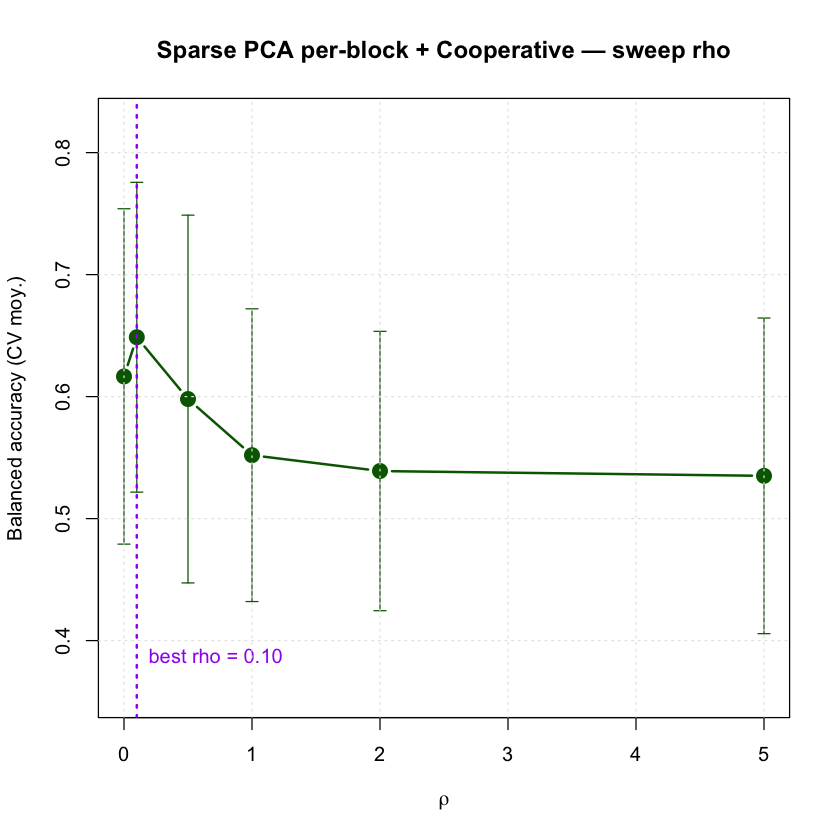

In [9]:
best_idx <- which.max(cv_results$mean_bal_acc)
best_rho <- cv_results$rho[best_idx]

plot(cv_results$rho, cv_results$mean_bal_acc,
     type = "b", pch = 19, cex = 1.5, col = "darkgreen", lwd = 2,
     xlab = expression(rho), ylab = "Balanced accuracy (CV moy.)",
     main = "Sparse PCA per-block + Cooperative — sweep rho",
     ylim = c(min(cv_results$mean_bal_acc - cv_results$sd_bal_acc, na.rm=TRUE) - 0.05,
              max(cv_results$mean_bal_acc + cv_results$sd_bal_acc, na.rm=TRUE) + 0.05))
arrows(cv_results$rho, cv_results$mean_bal_acc - cv_results$sd_bal_acc,
       cv_results$rho, cv_results$mean_bal_acc + cv_results$sd_bal_acc,
       length = 0.05, angle = 90, code = 3, col = "darkgreen")
abline(h = 1/3, col = "red", lty = 2)
abline(v = best_rho, col = "purple", lty = 3, lwd = 2)
text(best_rho, min(cv_results$mean_bal_acc - cv_results$sd_bal_acc) - 0.02,
     sprintf("best rho = %.2f", best_rho), col = "purple", pos = 4)
grid(col = "grey90")

cat(sprintf("\n>>> Meilleur rho : %.2f (CV bal_acc = %.3f ± %.3f)\n",
            best_rho,
            cv_results$mean_bal_acc[best_idx],
            cv_results$sd_bal_acc[best_idx]))


## 8. Refit final au meilleur ρ + évaluation test

In [10]:
set.seed(SEED)

# Refit la Sparse PCA sur tout le train + transformer test
spca_ge_final  <- fit_spca(X_ge_train,  N_COMP_GE,  KEEP_GE)
spca_cgh_final <- fit_spca(X_cgh_train, N_COMP_CGH, KEEP_CGH)

Z_ge_train_f  <- as.matrix(spca_ge_final$variates)
Z_cgh_train_f <- as.matrix(spca_cgh_final$variates)
Z_ge_test_f   <- project_spca(X_ge_test,  spca_ge_final)
Z_cgh_test_f  <- project_spca(X_cgh_test, spca_cgh_final)

sc_ge_f  <- scale(Z_ge_train_f)
sc_cgh_f <- scale(Z_cgh_train_f)
Z_ge_train_f  <- as.matrix(sc_ge_f)
Z_cgh_train_f <- as.matrix(sc_cgh_f)
Z_ge_test_f   <- scale(Z_ge_test_f,  center = attr(sc_ge_f, "scaled:center"),
                                       scale  = attr(sc_ge_f, "scaled:scale"))
Z_cgh_test_f  <- scale(Z_cgh_test_f, center = attr(sc_cgh_f, "scaled:center"),
                                       scale  = attr(sc_cgh_f, "scaled:scale"))

colnames(Z_ge_train_f)  <- paste0("GE_PC",  seq_len(ncol(Z_ge_train_f)))
colnames(Z_cgh_train_f) <- paste0("CGH_PC", seq_len(ncol(Z_cgh_train_f)))
colnames(Z_ge_test_f)   <- colnames(Z_ge_train_f)
colnames(Z_cgh_test_f)  <- colnames(Z_cgh_train_f)

# Refit cooperative au meilleur rho
coop_final <- fit_coop_ovr_at_rho(Z_ge_train_f, Z_cgh_train_f, y_train,
                                    rho = best_rho, verbose = TRUE)

# Prédiction test
pred_test_final <- predict_coop_argmax(coop_final, Z_ge_test_f, Z_cgh_test_f)
probs_test_final <- predict_coop_ovr_proba(coop_final, Z_ge_test_f, Z_cgh_test_f)

cat("\nProbabilités OvR sur test set :\n")
print(round(probs_test_final, 3))

cm_final <- caret::confusionMatrix(
  factor(pred_test_final, levels = LABEL_ORDER),
  factor(y_test, levels = LABEL_ORDER)
)
cat("\n=== Matrice de confusion test (Sparse PCA + Cooperative + argmax) ===\n")
print(cm_final$table)
cat(sprintf("\nAccuracy : %.3f\n", cm_final$overall["Accuracy"]))
cat(sprintf("Balanced accuracy : %.3f\n",
            mean(cm_final$byClass[, "Balanced Accuracy"])))
cat("\nBal_acc par classe :\n")
print(round(cm_final$byClass[, "Balanced Accuracy"], 3))


Warning message in mixOmics::spca(X_scaled, ncomp = ncomp, keepX = rep(keep_per_comp, :
“data contain missing values which will be set to zero for calculations. Consider using center = TRUE for better performance, or impute missing values using 'impute.nipals' function.”
Warning message in mixOmics::spca(X_scaled, ncomp = ncomp, keepX = rep(keep_per_comp, :
“data contain missing values which will be set to zero for calculations. Consider using center = TRUE for better performance, or impute missing values using 'impute.nipals' function.”


  rho=0.10 class=cort lambda.min=0.0336
  rho=0.10 class=dipg lambda.min=0.0242
  rho=0.10 class=midl lambda.min=0.0388

Probabilités OvR sur test set :
       cort  dipg  midl
 [1,] 0.614 0.205 0.122
 [2,] 0.514 0.203 0.269
 [3,] 0.091 0.729 0.147
 [4,] 0.359 0.382 0.207
 [5,] 0.218 0.716 0.134
 [6,] 0.345 0.574 0.143
 [7,] 0.219 0.603 0.070
 [8,] 0.630 0.237 0.125
 [9,] 0.207 0.689 0.176
[10,] 0.553 0.183 0.188
[11,] 0.460 0.391 0.128
[12,] 0.122 0.788 0.076
[13,] 0.573 0.227 0.250
[14,] 0.247 0.641 0.148

=== Matrice de confusion test (Sparse PCA + Cooperative + argmax) ===
          Reference
Prediction cort dipg midl
      cort    5    1    0
      dipg    0    5    3
      midl    0    0    0

Accuracy : 0.714
Balanced accuracy : 0.725

Bal_acc par classe :
Class: cort Class: dipg Class: midl 
      0.944       0.729       0.500 


## 9. Comparaison avec les autres pipelines

| Méthode | Préprocessing | Classifieur final | CV bal_acc | Test bal_acc |
|---|---|---|---|---|
| SGCCA + LDA (NB09) | SGCCA → 2 comp | LDA | 0.829 ± 0.143 | 0.924 |
| Coop + LDA (NB10) | Cooperative raw + filtre | LDA | 0.829 ± 0.148 | 0.924 |
| Coop argmax (NB11) | Cooperative raw | argmax OvR | 0.833 ± 0.129 | 0.924 |
| **Sparse PCA + Coop + argmax (NB12)** | **Sparse PCA per-block** | **argmax OvR** | **(ce notebook)** | **(ce notebook)** |


In [11]:
# Hardcode des valeurs précédentes (à actualiser si réexécutés)
nb09_cv      <- "0.829 ± 0.143";  nb09_test <- 0.924
nb10_cv      <- "0.829 ± 0.148";  nb10_test <- 0.924
nb11_cv      <- "0.833 ± 0.129";  nb11_test <- 0.924

nb12_cv_mean <- cv_results$mean_bal_acc[best_idx]
nb12_cv_sd   <- cv_results$sd_bal_acc[best_idx]
nb12_cv      <- sprintf("%.3f ± %.3f", nb12_cv_mean, nb12_cv_sd)
nb12_test    <- mean(cm_final$byClass[, "Balanced Accuracy"])

comparison <- data.frame(
  Notebook = c("NB09 SGCCA+LDA", "NB10 Coop+LDA", "NB11 Coop argmax",
               sprintf("NB12 sPCA+Coop+argmax (rho=%.2f)", best_rho)),
  CV_bal_acc = c(nb09_cv, nb10_cv, nb11_cv, nb12_cv),
  Test_bal_acc = c(sprintf("%.3f", nb09_test),
                   sprintf("%.3f", nb10_test),
                   sprintf("%.3f", nb11_test),
                   sprintf("%.3f", nb12_test))
)
print(comparison, row.names = FALSE)

cat("\n========== DIAGNOSTIC ==========\n")
delta_vs_nb11 <- nb12_cv_mean - 0.833
cat(sprintf("Δ NB12 - NB11 (Coop raw) : %+.3f\n", delta_vs_nb11))
if (abs(delta_vs_nb11) < 0.02) {
  cat("→ NB12 ≈ NB11. La Sparse PCA per-block ne change rien sur ce dataset.\n")
} else if (delta_vs_nb11 > 0) {
  cat("→ NB12 > NB11. La Sparse PCA per-block apporte un gain.\n")
} else {
  cat("→ NB12 < NB11. La Sparse PCA per-block est délétère (sur-réduction).\n")
}

cat(sprintf("\nMeilleur rho dans NB12 : %.2f\n", best_rho))
if (best_rho > 0) {
  cat("→ L'agrément cooperative apporte quelque chose ! Premier régime ρ > 0 utile.\n")
} else {
  cat("→ Même en réduit, l'optimum reste à rho=0 (Lasso multi-bloc sparse).\n")
}


                         Notebook    CV_bal_acc Test_bal_acc
                   NB09 SGCCA+LDA 0.829 ± 0.143        0.924
                    NB10 Coop+LDA 0.829 ± 0.148        0.924
                 NB11 Coop argmax 0.833 ± 0.129        0.924
 NB12 sPCA+Coop+argmax (rho=0.10) 0.649 ± 0.127        0.725

========== DIAGNOSTIC ==========
Δ NB12 - NB11 (Coop raw) : -0.184
→ NB12 < NB11. La Sparse PCA per-block est délétère (sur-réduction).

Meilleur rho dans NB12 : 0.10
→ L'agrément cooperative apporte quelque chose ! Premier régime ρ > 0 utile.


## 10. Lecture des résultats

Trois résultats possibles, par ordre d'intérêt scientifique :

### Scénario A — NB12 > NB11 ET best_rho > 0

**Découverte majeure.** La Sparse PCA per-block rend le solveur capable d'exploiter l'agrément cooperative pour ρ > 0, et l'optimum réel est intermédiaire. Cela validerait empiriquement la philosophie cooperative (intermédiaire entre fusion précoce et tardive) pour ce dataset.

Pour le rapport :
> *"En réduisant la dimensionnalité au préalable par Sparse PCA per-block, l'optimisation cooperative devient tractable pour ρ > 0. L'optimum trouvé à ρ = X confirme empiriquement la pertinence de l'agrément cross-blocs sur ce dataset, après réduction adaptée."*

### Scénario B — NB12 ≈ NB11 (même score) ET best_rho ≈ 0

Confirme que le signal est porté par la sélection sparse et non par la réduction de dim particulière. Cooperative est invariant à la pré-réduction tant qu'on garde l'essentiel.

Pour le rapport :
> *"La Sparse PCA per-block en amont de cooperative ne modifie pas les performances. L'invariance suggère que la sélection sparse de cooperative est suffisante pour extraire l'information utile, sans réduction supplémentaire."*

### Scénario C — NB12 < NB11

Sparse PCA per-block coûte de l'information. La réduction préalable à 10/5 composantes jette trop de signal.

Pour le rapport :
> *"La réduction par Sparse PCA à 10 composantes GE et 5 CGH est trop agressive sur ce dataset : elle dégrade les performances comparé à cooperative sur features brutes. La cooperative seul gère mieux la haute dimensionnalité que ce pipeline en deux étapes."*

Quel que soit le scénario, **on aura un résultat informatif** pour le tuteur.
